In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (confusion_matrix, precision_score, recall_score,
                             f1_score, fbeta_score, average_precision_score,
                                                          precision_recall_curve, auc, classification_report)
from sklearn.exceptions import UndefinedMetricWarning
import warnings

warnings.filterwarnings("ignore", category=UndefinedMetricWarning)


In [4]:
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [5]:
df.columns = df.columns.str.lower()
df

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [6]:
df.describe().round()

,seniorcitizen,tenure,monthlycharges
count,7043.0,7043.0,7043.0
mean,0.0,32.0,65.0
std,0.0,25.0,30.0
min,0.0,0.0,18.0
25%,0.0,9.0,36.0
50%,0.0,29.0,70.0
75%,0.0,55.0,90.0
max,1.0,72.0,119.0


In [7]:
df.isna().sum()

,0
customerid,0
gender,0
seniorcitizen,0
partner,0
dependents,0
tenure,0
phoneservice,0
multiplelines,0
internetservice,0
onlinesecurity,0


In [8]:
df.nunique()

,0
customerid,7043
gender,2
seniorcitizen,2
partner,2
dependents,2
tenure,73
phoneservice,2
multiplelines,3
internetservice,3
onlinesecurity,3


In [9]:
del df['customerid']
del df['phoneservice']
del df['gender']
del df['totalcharges']

In [10]:
df['fiber_optic'] = (df['internetservice'] == 'Fiber optic').map({True: 'Yes', False: 'No'})

In [11]:
del df['internetservice']

In [12]:
df['electronic_check'] = (df['paymentmethod'] == 'Electronic check').map({True: 'Yes', False: 'No'})

In [13]:
del df['paymentmethod']

In [14]:
services = [
    'streamingmovies',
    'streamingtv',
    'techsupport',
    'deviceprotection',
    'onlinebackup',
    'onlinesecurity'
]

df['additional_services'] = (
    df[services]
    .apply(lambda col: col == 'Yes')
    .sum(axis=1)
)

In [15]:
del df['streamingmovies']
del df['streamingtv']
del df['techsupport']
del df['deviceprotection']
del df['onlinebackup']
del df['onlinesecurity']

In [16]:
df.columns

Index(['seniorcitizen', 'partner', 'dependents', 'tenure', 'multiplelines',
       'contract', 'paperlessbilling', 'monthlycharges', 'churn',
       'fiber_optic', 'electronic_check', 'additional_services'],
      dtype='object')

In [17]:
df.dtypes

,0
seniorcitizen,int64
partner,object
dependents,object
tenure,int64
multiplelines,object
contract,object
paperlessbilling,object
monthlycharges,float64
churn,object
fiber_optic,object


In [18]:
df['churn'].value_counts()

,count
churn,
No,5174
Yes,1869


In [19]:
y = df['churn']
X = df.drop(columns=['churn'])

In [20]:
y = y.map({
    "No": 0,
    "Yes": 1
})

In [21]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=11
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=11
)

In [22]:
cat_cols = ['partner', 'dependents',
        'multiplelines', 'fiber_optic', 'electronic_check', 'paperlessbilling']
num_cols = [c for c in X.columns if c not in cat_cols and c != 'contract']
contract_col = ['contract']

In [23]:
num_cols

['seniorcitizen', 'tenure', 'monthlycharges', 'additional_services']

In [24]:
cat_cols

['partner',
 'dependents',
 'multiplelines',
 'fiber_optic',
 'electronic_check',
 'paperlessbilling']

In [25]:
contract_order = [['Month-to-month', 'One year', 'Two year']]

In [26]:
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [27]:
for col in num_cols:
    df[col] = df[col].replace(r'^\s*$', np.nan, regex=True)

In [28]:
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ("scaler", StandardScaler())
                    ]), num_cols),
    ("contract", OrdinalEncoder(categories=contract_order), contract_col),
    ("cat", OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
                                ])

In [35]:
pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("svc", SVC(
        class_weight='balanced',
        probability=True,
        random_state=11
    ))
])

param_grid = {
    "svc__C": [0.1, 1, 10, 100],
    "svc__gamma": ["scale", 0.001, 0.01, 0.1],
    "svc__kernel": ["rbf"]
}

grid_search = GridSearchCV(
    pipe,
    param_grid,
    scoring="average_precision",
    cv=2,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

print("Grid best params:", grid_search.best_params_)
print("Grid best AP:", grid_search.best_score_)

Fitting 2 folds for each of 16 candidates, totalling 32 fits
Grid best params: {'svc__C': 100, 'svc__gamma': 0.001, 'svc__kernel': 'rbf'}
Grid best AP: 0.6559423849484292


In [36]:
param_dist = {
    "svc__C": loguniform(10, 100),
    "svc__gamma": loguniform(1e-3, 1e-1),
    "svc__kernel": ["rbf"]
}

random_search = RandomizedSearchCV(
    pipe,
    param_distributions=param_dist,
    n_iter=40,
    scoring="average_precision",
    cv=4,
    random_state=11,
    n_jobs=-1,
    verbose=2
)

random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_
print("Random best params:", random_search.best_params_)
print("Random best AP:", random_search.best_score_)

Fitting 4 folds for each of 40 candidates, totalling 160 fits
Random best params: {'svc__C': np.float64(53.698786341356396), 'svc__gamma': np.float64(0.0016499551674690434), 'svc__kernel': 'rbf'}
Random best AP: 0.6578247258183377


In [37]:
c_value = round(random_search.best_params_['svc__C'], 2)
gamma_value = round(random_search.best_params_['svc__gamma'], 3)

In [38]:
results = pd.DataFrame(random_search.cv_results_)

results[
    ['param_svc__C', 'param_svc__gamma',
     'mean_test_score', 'std_test_score']
].sort_values(by='mean_test_score', ascending=False).head()

,param_svc__C,param_svc__gamma,mean_test_score,std_test_score
5,53.698786,0.001650,0.657825,0.025052
11,22.111820,0.004341,0.657819,0.023868
20,11.579410,0.005361,0.657798,0.023556
21,11.749592,0.004352,0.657711,0.024856
22,11.759330,0.003807,0.656993,0.024934


In [39]:
calibrated_model = CalibratedClassifierCV(
    estimator=best_model,
    method='sigmoid',
    cv=5
)
calibrated_model.fit(X_val, y_val)

CalibratedClassifierCV(cv=5,
                       estimator=Pipeline(steps=[('preprocessor',
                                                  ColumnTransformer(transformers=[('num',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer(strategy='median')),
                                                                                                   ('scaler',
                                                                                                    StandardScaler())]),
                                                                                   ['seniorcitizen',
                                                                                    'tenure',
                                                                                    'monthlycharges',
                                                                                    'additional_services']),
                                                                                  ('contract',
                                                                                   OrdinalEncoder(categories=[['Month-to-month',
                                                                                                               'One '
                                                                                                               'year',
                                                                                                               'Two '
                                                                                                               'year']]),
                                                                                   ['contract']),
                                                                                  ('cat',
                                                                                   OneHotEncoder(drop='first',
                                                                                                 handle_unknown='ignore'),
                                                                                   ['partner',
                                                                                    'dependents',
                                                                                    'multiplelines',
                                                                                    'fiber_optic',
                                                                                    'electronic_check',
                                                                                    'paperlessbilling'])])),
                                                 ('svc',
                                                  SVC(C=np.float64(53.698786341356396),
                                                      class_weight='balanced',
                                                      gamma=np.float64(0.0016499551674690434),
                                                      probability=True,
                                                      random_state=11))]))

In [40]:
y_prob_val = calibrated_model.predict_proba(X_val)[:,1]
y_pred_val = (y_prob_val >= 0.5).astype(int)

print("Confusion Matrix (Validation):")
print(confusion_matrix(y_val, y_pred_val))

print("\nClassification Report (Validation):")
print(classification_report(y_val, y_pred_val))

print("\nAverage Precision (Validation):", average_precision_score(y_val, y_prob_val))

Confusion Matrix (Validation):
[[689  87]
 [120 160]]

Classification Report (Validation):
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       776
           1       0.65      0.57      0.61       280

    accuracy                           0.80      1056
   macro avg       0.75      0.73      0.74      1056
weighted avg       0.80      0.80      0.80      1056


Average Precision (Validation): 0.6357126833681496


In [41]:
y_prob_val_uncal = best_model.predict_proba(X_val)[:, 1]
y_pred_val_uncal = (y_prob_val_uncal >= 0.5).astype(int)

print("Confusion Matrix (Validation):")
print(confusion_matrix(y_val, y_pred_val_uncal))

print("\nClassification Report (Validation):")
print(classification_report(y_val, y_pred_val_uncal, target_names=["No-Churn", "Churn"]))

ap_val = average_precision_score(y_val, y_prob_val_uncal)
print("\nAverage Precision (Validation):", ap_val)

Confusion Matrix (Validation):
[[693  83]
 [126 154]]

Classification Report (Validation):
              precision    recall  f1-score   support

    No-Churn       0.85      0.89      0.87       776
       Churn       0.65      0.55      0.60       280

    accuracy                           0.80      1056
   macro avg       0.75      0.72      0.73      1056
weighted avg       0.79      0.80      0.80      1056


Average Precision (Validation): 0.6349292084020783


In [42]:
def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.xticks([0.5,1.5], ['No Churn (0)', 'Churn (1)'])
    plt.yticks([0.5,1.5], ['No Churn (0)', 'Churn (1)'], rotation=0)
    plt.show()

Test metrike (threshold=0.5):
Precision: 0.6477732793522267
Recall: 0.5714285714285714
F1: 0.6072106261859582
PR AUC: 0.6357126833681496


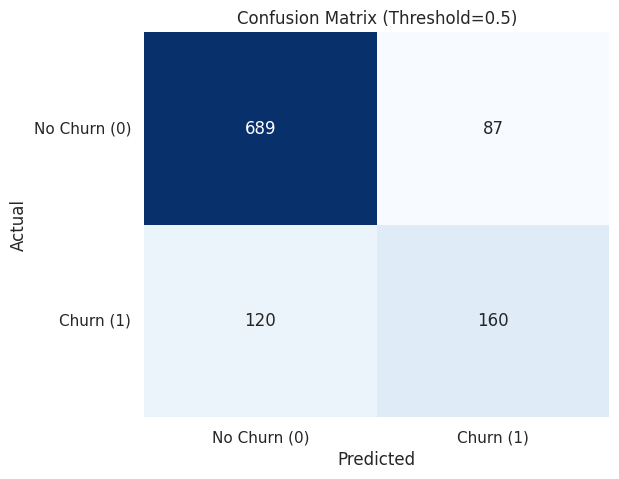

In [43]:
print("Test metrike (threshold=0.5):")
print("Precision:", precision_score(y_val, y_pred_val))
print("Recall:", recall_score(y_val, y_pred_val))
print("F1:", f1_score(y_val, y_pred_val))
print("PR AUC:", average_precision_score(y_val, y_prob_val))
plot_confusion_matrix(y_val, y_pred_val, title='Confusion Matrix (Threshold=0.5)')

In [44]:
thresholds = np.linspace(0, 1, 300)
best_f2, best_thr = 0, 0
for thr in thresholds:
    y_pred_thr = (y_prob_val >= thr).astype(int)
    f2 = fbeta_score(y_val, y_pred_thr, beta=2)
    if f2 > best_f2:
        best_f2 = f2
        best_thr = thr

print("Best threshold:", best_thr)
print("Best F2 on val:", best_f2)

Best threshold: 0.16387959866220736
Best F2 on val: 0.7637655417406749


Final metrics (optimal threshold):
Precision: 0.45342706502636204
Recall: 0.9214285714285714
F1: 0.607773851590106


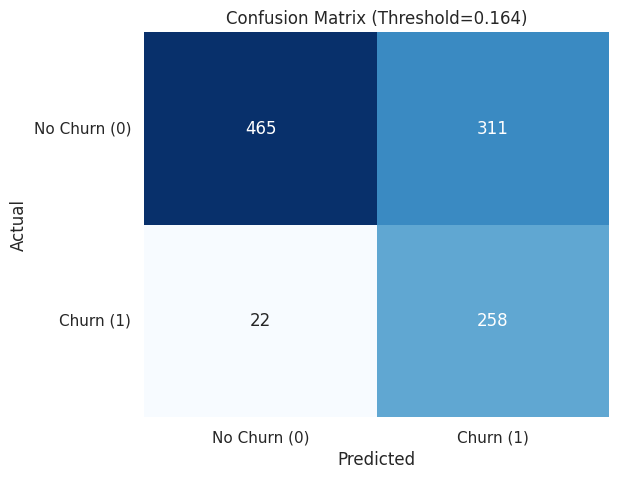

In [45]:
y_pred_final = (y_prob_val >= best_thr).astype(int)
print("Final metrics (optimal threshold):")
print("Precision:", precision_score(y_val, y_pred_final))
print("Recall:", recall_score(y_val, y_pred_final))
print("F1:", f1_score(y_val, y_pred_final))
plot_confusion_matrix(y_val, y_pred_final, title=f'Confusion Matrix (Threshold={best_thr:.3f})')

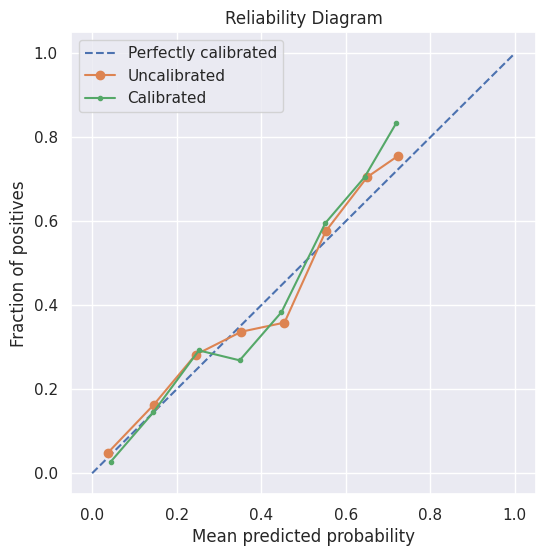

In [46]:
fop_cal, mpv_cal = calibration_curve(y_val, y_prob_val, n_bins=10)
fop_uncal, mpv_uncal = calibration_curve(y_val, y_prob_val_uncal, n_bins=10)

plt.figure(figsize=(6,6))
plt.plot([0,1],[0,1],'--', label='Perfectly calibrated')
plt.plot(mpv_uncal, fop_uncal, marker='o', label='Uncalibrated')
plt.plot(mpv_cal, fop_cal, marker='.', label='Calibrated')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Reliability Diagram')
plt.legend()
plt.grid(True)
plt.show()

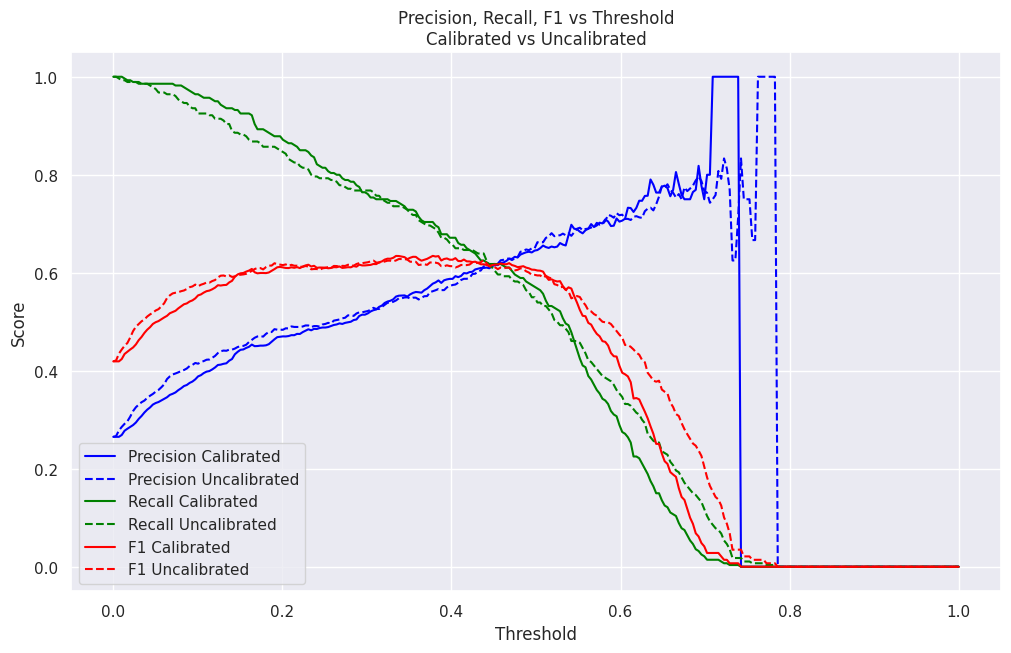

In [47]:
thresholds = np.linspace(0, 1, 300)

precision_cal, recall_cal, f1_cal = [], [], []
precision_uncal, recall_uncal, f1_uncal = [], [], []

for thr in thresholds:
    # Kalibrisani
    y_pred_cal = (y_prob_val >= thr).astype(int)
    precision_cal.append(precision_score(y_val, y_pred_cal))
    recall_cal.append(recall_score(y_val, y_pred_cal))
    f1_cal.append(f1_score(y_val, y_pred_cal))

    # Nekalibrisani
    y_pred_uncal = (y_prob_val_uncal >= thr).astype(int)
    precision_uncal.append(precision_score(y_val, y_pred_uncal))
    recall_uncal.append(recall_score(y_val, y_pred_uncal))
    f1_uncal.append(f1_score(y_val, y_pred_uncal))

plt.figure(figsize=(12, 7))

# Precision
plt.plot(thresholds, precision_cal, label='Precision Calibrated', color='blue', linestyle='-')
plt.plot(thresholds, precision_uncal, label='Precision Uncalibrated', color='blue', linestyle='--')

# Recall
plt.plot(thresholds, recall_cal, label='Recall Calibrated', color='green', linestyle='-')
plt.plot(thresholds, recall_uncal, label='Recall Uncalibrated', color='green', linestyle='--')

# F1
plt.plot(thresholds, f1_cal, label='F1 Calibrated', color='red', linestyle='-')
plt.plot(thresholds, f1_uncal, label='F1 Uncalibrated', color='red', linestyle='--')

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision, Recall, F1 vs Threshold\nCalibrated vs Uncalibrated')
plt.legend(loc='best')
plt.grid(True)
plt.show()

In [48]:
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

In [49]:
final_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("svc", SVC(
        kernel="rbf",
        C=c_value,
        gamma=gamma_value,
        probability=True
    ))
])

In [50]:
final_pipeline.fit(X_train_full, y_train_full)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['seniorcitizen', 'tenure',
                                                   'monthlycharges',
                                                   'additional_services']),
                                                 ('contract',
                                                  OrdinalEncoder(categories=[['Month-to-month',
                                                                              'One '
                                                                              'year',
                                                                              'Two '
                                                                              'year']]),
                                                  ['contract']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['partner', 'dependents',
                                                   'multiplelines',
                                                   'fiber_optic',
                                                   'electronic_check',
                                                   'paperlessbilling'])])),
                ('svc',
                 SVC(C=np.float64(53.7), gamma=np.float64(0.002),
                     probability=True))])

In [51]:
calibrated_model = CalibratedClassifierCV(
    estimator=final_pipeline,
    method="sigmoid",
    cv=5
)

calibrated_model.fit(X_train_full, y_train_full)

CalibratedClassifierCV(cv=5,
                       estimator=Pipeline(steps=[('preprocessor',
                                                  ColumnTransformer(transformers=[('num',
                                                                                   Pipeline(steps=[('imputer',
                                                                                                    SimpleImputer(strategy='median')),
                                                                                                   ('scaler',
                                                                                                    StandardScaler())]),
                                                                                   ['seniorcitizen',
                                                                                    'tenure',
                                                                                    'monthlycharges',
                                                                                    'additional_services']),
                                                                                  ('contract',
                                                                                   OrdinalEncoder(categories=[['Month-to-month',
                                                                                                               'One '
                                                                                                               'year',
                                                                                                               'Two '
                                                                                                               'year']]),
                                                                                   ['contract']),
                                                                                  ('cat',
                                                                                   OneHotEncoder(drop='first',
                                                                                                 handle_unknown='ignore'),
                                                                                   ['partner',
                                                                                    'dependents',
                                                                                    'multiplelines',
                                                                                    'fiber_optic',
                                                                                    'electronic_check',
                                                                                    'paperlessbilling'])])),
                                                 ('svc',
                                                  SVC(C=np.float64(53.7),
                                                      gamma=np.float64(0.002),
                                                      probability=True))]))

In [52]:
y_test_proba = calibrated_model.predict_proba(X_test)[:, 1]

In [53]:
y_test_pred = (y_test_proba >= best_thr).astype(int)

In [54]:
print("AP:", average_precision_score(y_test, y_test_proba))
print("Recall:", recall_score(y_test, y_test_pred))
print("Precision:", precision_score(y_test, y_test_pred))
print("F2:", fbeta_score(y_test, y_test_pred, beta=2))

AP: 0.6382332429794486
Recall: 0.9145907473309609
Precision: 0.4812734082397004
F2: 0.7750301568154403


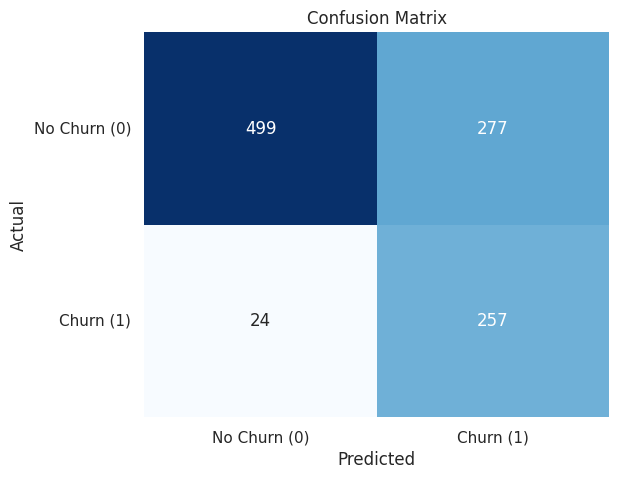

In [55]:
plot_confusion_matrix(y_test, y_test_pred, title='Confusion Matrix')